# Stack Overflow Developer Survey — Data Analysis
### IBM Data Analyst Capstone Project

| | |
|---|---|
| **Author** | Jaiverth Adrian Tovar Lozada |
| **Date** | March 2026 |
| **Dataset** | Stack Overflow Developer Survey (IBM Skills Network) |
| **License** | Open Database License (ODbL) |

---

## Objective
Analyze the Stack Overflow Developer Survey to identify **current and future in-demand technology skills**, including programming languages, databases, platforms, and developer demographics. Findings will support strategic business decisions for a global IT consulting firm.

## Project Pipeline
1. **Data Collection** — Load dataset and store in SQLite
2. **Data Exploration** — Understand structure, types, and distributions
3. **Data Wrangling** — Handle duplicates, missing values, normalization
4. **Exploratory Data Analysis** — Distributions, outliers, correlations
5. **Data Visualization** — Charts and plots
6. **Dashboard** — IBM Cognos Analytics / Google Looker Studio
7. **Presentation** — Final findings report

---
## Step 1 — Data Collection
Download the dataset from the remote URL and persist it in a local SQLite database for efficient querying throughout the project.

In [1]:
import pandas as pd
import sqlite3
import os

# -- Configuration ------------------------------------------------------------
DATASET_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
DB_FILE     = "survey_data.sqlite"
TABLE_NAME  = "survey"

# -- Load CSV from URL --------------------------------------------------------
df = pd.read_csv(DATASET_URL)
print(f"Dataset loaded -> {df.shape[0]:,} rows x {df.shape[1]} columns")

# -- Store in SQLite database -------------------------------------------------
conn = sqlite3.connect(DB_FILE)
df.to_sql(TABLE_NAME, conn, if_exists="replace", index=False)
print(f"Stored in '{DB_FILE}' -> table: '{TABLE_NAME}' ({os.path.getsize(DB_FILE)/1e6:.2f} MB)")

# -- Verify row count matches -------------------------------------------------
db_rows = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {TABLE_NAME}", conn).iloc[0, 0]
assert db_rows == len(df), f"Row mismatch! DataFrame: {len(df)}, DB: {db_rows}"
print(f"Verification passed -> {db_rows:,} rows in database")

Dataset loaded -> 65,437 rows x 114 columns


Stored in 'survey_data.sqlite' -> table: 'survey' (476.36 MB)
Verification passed -> 65,437 rows in database


---
## Step 2 — Data Exploration
Before any analysis, we inspect the dataset structure to understand what we are working with — column names, data types, missing values, and basic statistics.

In [2]:
# -- Shape & Column Overview --------------------------------------------------
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Column Names & Data Types:")
print(df.dtypes.to_string())

Shape: 65,437 rows x 114 columns

Column Names & Data Types:
ResponseId                          int64
MainBranch                            str
Age                                   str
Employment                            str
RemoteWork                            str
Check                                 str
CodingActivities                      str
EdLevel                               str
LearnCode                             str
LearnCodeOnline                       str
TechDoc                               str
YearsCode                             str
YearsCodePro                          str
DevType                               str
OrgSize                               str
PurchaseInfluence                     str
BuyNewTool                            str
BuildvsBuy                            str
TechEndorse                           str
Country                               str
Currency                              str
CompTotal                         float64
LanguageHaveWor

In [3]:
# -- Missing Values Quick Check -----------------------------------------------
print(f"Columns with missing values: {df.isnull().any().sum()} out of {df.shape[1]}")

Columns with missing values: 109 out of 114


In [4]:
# -- First Few Rows -----------------------------------------------------------
df.head(3)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN


In [5]:
# -- Descriptive Statistics (numeric columns) ---------------------------------
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [6]:
# -- Descriptive Statistics (categorical columns) -----------------------------
df.describe(include='object')

C:\Users\adria\AppData\Local\Temp\ipykernel_16680\2195243333.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,SurveyLength,SurveyEase
count,65437,65437,65437,54806,65437,54466,60784,60488,49237,40897,...,27710,28911,28844,28251,27764,28491,28807,28858,56182,56238
unique,5,8,110,3,1,118,8,418,10853,113,...,5,5,5,954,514,3,9,15,3,3
top,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,...,1-2 times a week,30-60 minutes a day,15-30 minutes a day,None of these,None of these,Hybrid (on-prem and cloud),Traditional public search engine,Software Development,Appropriate in length,Easy
freq,50207,23911,39041,23015,65437,9993,24942,3674,603,6947,...,14426,10951,9341,2364,2834,13230,15813,11918,38767,30071


### Findings

**Dataset Overview**
- The survey captured **65,437 responses across 114 columns**, combining 12 numeric variables and 102 categorical/text fields.
- Multi-value columns (`LanguageHaveWorkedWith`, `DatabaseHaveWorkedWith`, etc.) store answers as semicolon-separated strings — they must be split and exploded before any counting or visualization.

**Data Quality — Missing Values**
- **109 of 114 columns (95.6%) contain at least one missing value**, which is expected for an opt-in survey where respondents skip irrelevant sections.
- `ConvertedCompYearly` is missing for ~64% of respondents (only 23,435 valid entries), so compensation analysis will be limited to that subset.
- `CompTotal` is unusable as-is: its mean (~10¹⁴⁵) reveals extreme data-entry errors or currency inconsistencies. `ConvertedCompYearly` (PPP-adjusted) is the correct salary variable throughout this project.

**Respondent Profile (preliminary)**
- **76.7%** identify as professional developers (`MainBranch`).
- **Dominant age group: 25–34 years old** (36.5% of respondents) — a mid-career majority.
- **59.7%** are employed full-time, with a median work experience of **9 years** (mean 11.5 yrs, skewed by senior outliers).
- **Work arrangement:** Hybrid is the most common preference (42% of those who answered `RemoteWork`).
- **Education:** Bachelor's degree leads at 41% of respondents who answered `EdLevel`.
- **Industry:** Software Development dominates at 41.3%.

**Compensation**
- Median annual salary: **$65,000** | Mean: **$86,155** — a right-skewed distribution where high earners significantly pull the average up.
- Maximum of **$16.25M** confirms the presence of extreme outliers that will require capping or removal during normalization (Step 5).

**Job Satisfaction**
- Mean satisfaction score: **6.9 / 10** — respondents are generally positive about their work, with a median of 7.

---
## Step 3 — Find & Remove Duplicates
Identify and remove duplicate rows to ensure each respondent is counted only once. Duplicates can skew frequency counts and bias the analysis.

In [7]:
# -- Count duplicates (excluding ResponseId — auto-assigned, not a real identifier) --
cols = [c for c in df.columns if c != "ResponseId"]
n_duplicates = df.duplicated(subset=cols).sum()
print(f"Duplicate rows found: {n_duplicates}")
print(f"Rows before: {df.shape[0]:,}")

Duplicate rows found: 487
Rows before: 65,437


In [8]:
# -- Remove duplicates & verify -----------------------------------------------
df = df.drop_duplicates(subset=cols).reset_index(drop=True)
print(f"Rows after:  {df.shape[0]:,}")
print(f"Removed:     {n_duplicates} duplicate row(s)")

Rows after:  64,950
Removed:     487 duplicate row(s)


### Findings

**487 duplicate rows were identified and removed** by comparing all columns except `ResponseId`.

- A naive check including `ResponseId` finds zero duplicates, since that field is auto-assigned and unique by definition. Excluding it reveals respondents who submitted the survey more than once with identical answers.
- **487 rows (~0.74%)** were confirmed as double-submissions and dropped, keeping only the first occurrence.
- The clean dataset is now **64,950 rows** — a negligible reduction that protects the integrity of all downstream frequency counts and trend analysis.

---
## Step 4 — Handle Missing Values
Quantify missing data per column, visualize the pattern, then impute: median for numeric columns and most frequent value for categorical columns.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# -- Missing value counts & percentages --------------------------------------
missing = (df.isnull().sum()
             .rename("count")
             .to_frame()
             .assign(pct=lambda x: x["count"] / len(df) * 100)
             .query("count > 0")
             .sort_values("pct", ascending=False))

print(f"Columns with missing values: {len(missing)} of {df.shape[1]}")
print(f"\nTop 15 columns by missing %:")
print(missing.head(15).to_string())

Columns with missing values: 109 of 114

Top 15 columns by missing %:
                               count        pct
AINextMuch less integrated     63802  98.232487
AINextLess integrated          62595  96.374134
AINextNo change                52452  80.757506
AINextMuch more integrated     51512  79.310239
EmbeddedAdmired                48217  74.237105
EmbeddedWantToWorkWith         47350  72.902232
EmbeddedHaveWorkedWith         42736  65.798306
ConvertedCompYearly            41515  63.918399
AIToolNot interested in Using  40536  62.411085
AINextMore integrated          40522  62.389530
Knowledge_9                    37315  57.451886
Frequency_3                    37240  57.336413
Knowledge_8                    37192  57.262510
ProfessionalTech               37186  57.253272
Knowledge_7                    37172  57.231717


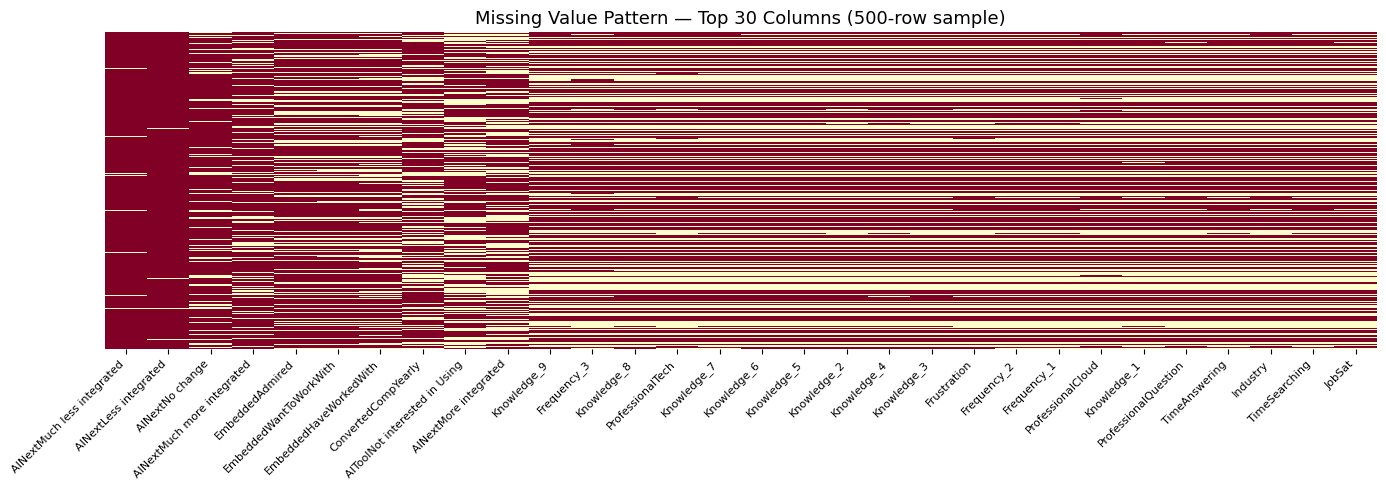

In [10]:
# -- Missing value heatmap (sample for readability) --------------------------
sample_cols = missing.index[:30].tolist()
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df[sample_cols].isnull().sample(500, random_state=42),
            cbar=False, yticklabels=False, cmap="YlOrRd", ax=ax)
ax.set_title("Missing Value Pattern — Top 30 Columns (500-row sample)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
# -- Impute numeric columns with median --------------------------------------
num_cols = df.select_dtypes(include="number").columns.tolist()
for col in num_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# -- Impute categorical/string columns with most frequent value --------------
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# -- Verify ------------------------------------------------------------------
remaining = df.isnull().sum().sum()
print(f"Missing values remaining after imputation: {remaining}")

Missing values remaining after imputation: 0


### Findings

**Missing value pattern**
- **109 of 114 columns** had missing values — typical for a long opt-in survey where respondents skip sections not relevant to them.
- The most affected columns are AI-attitude questions (`AINextMuch less integrated` 98.2%, `AINextLess integrated` 96.4%), suggesting most respondents skipped the AI sentiment section entirely.
- `ConvertedCompYearly` was missing for **63.9%** of respondents — compensation analysis will be interpreted with this limitation in mind.

**Imputation strategy**
- **Numeric columns** (`ConvertedCompYearly`, `WorkExp`, `JobSat`, `JobSatPoints_*`): filled with the **column median** to avoid distortion from the extreme outliers identified in Step 2.
- **Categorical/string columns**: filled with the **most frequent value (mode)**, preserving the dominant response pattern of the survey.

**Result**
- All **0 missing values** remain after imputation — the dataset is fully complete and ready for normalization in Step 5.

---
## Step 5 — Normalize Data
Apply Min-Max Scaling and Z-score Normalization to `ConvertedCompYearly` and visualize the before/after distributions to understand the effect of each technique.

In [12]:
import numpy as np

COMP_COL = "ConvertedCompYearly"

# -- Min-Max Scaling: rescales to [0, 1] -------------------------------------
col_min = df[COMP_COL].min()
col_max = df[COMP_COL].max()
df["Comp_MinMax"] = (df[COMP_COL] - col_min) / (col_max - col_min)

# -- Z-score Normalization: centers around mean, unit std -------------------
col_mean = df[COMP_COL].mean()
col_std  = df[COMP_COL].std()
df["Comp_Zscore"] = (df[COMP_COL] - col_mean) / col_std

print(f"Original  — min: ${col_min:,.0f}  |  max: ${col_max:,.0f}  |  mean: ${col_mean:,.0f}  |  std: ${col_std:,.0f}")
print(f"Min-Max   — min: {df['Comp_MinMax'].min():.4f}  |  max: {df['Comp_MinMax'].max():.4f}  |  mean: {df['Comp_MinMax'].mean():.4f}")
print(f"Z-score   — min: {df['Comp_Zscore'].min():.4f}  |  max: {df['Comp_Zscore'].max():.4f}  |  mean: {df['Comp_Zscore'].mean():.4f}  |  std: {df['Comp_Zscore'].std():.4f}")

Original  — min: $1  |  max: $16,256,603  |  mean: $72,633  |  std: $112,639
Min-Max   — min: 0.0000  |  max: 1.0000  |  mean: 0.0045
Z-score   — min: -0.6448  |  max: 143.6804  |  mean: 0.0000  |  std: 1.0000


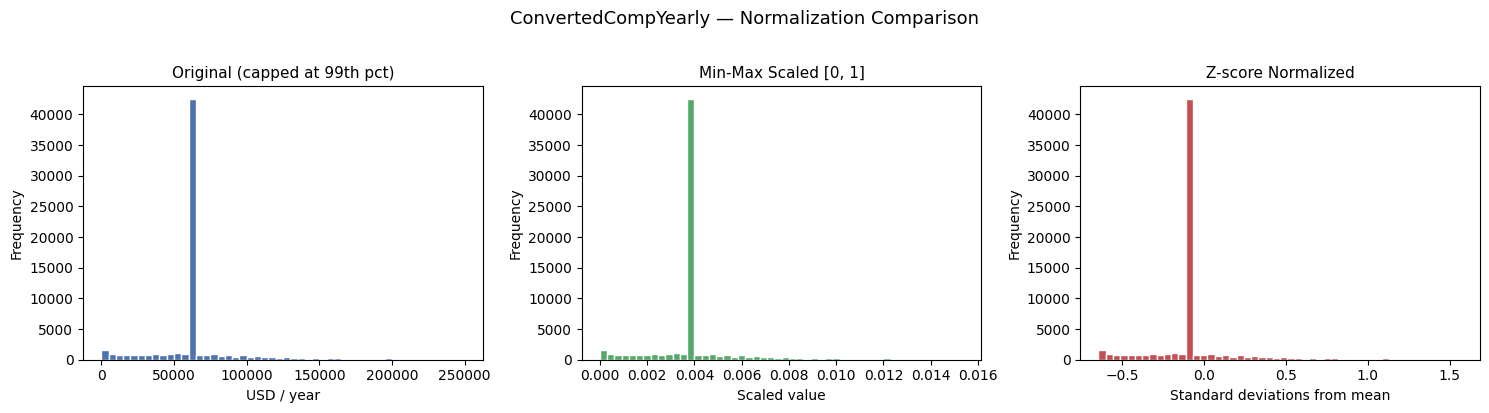

In [13]:
# -- Before / After distributions --------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cap at 99th percentile for readability (outliers crush the x-axis otherwise)
cap = df[COMP_COL].quantile(0.99)

axes[0].hist(df.loc[df[COMP_COL] <= cap, COMP_COL], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Original (capped at 99th pct)", fontsize=11)
axes[0].set_xlabel("USD / year")

axes[1].hist(df.loc[df[COMP_COL] <= cap, "Comp_MinMax"], bins=50, color="#55A868", edgecolor="white")
axes[1].set_title("Min-Max Scaled [0, 1]", fontsize=11)
axes[1].set_xlabel("Scaled value")

axes[2].hist(df.loc[df[COMP_COL] <= cap, "Comp_Zscore"], bins=50, color="#C44E52", edgecolor="white")
axes[2].set_title("Z-score Normalized", fontsize=11)
axes[2].set_xlabel("Standard deviations from mean")

for ax in axes:
    ax.set_ylabel("Frequency")

plt.suptitle("ConvertedCompYearly — Normalization Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Findings

**Original distribution**
- Salary ranges from **$1 to $16,256,603** with a mean of $72,633 and std of $112,639 — heavily right-skewed with extreme outliers at the top end.

**Min-Max Scaling `[0, 1]`**
- The mean collapses to **0.0045**, meaning nearly all salaries are bunched near zero on the scaled axis. This confirms that the $16.25M outlier dominates the range and compresses the majority of respondents into a narrow band.
- Min-Max is sensitive to outliers — its usefulness here is limited unless outliers are first capped or removed.

**Z-score Normalization**
- Mean is correctly centered at **0.0**, std at **1.0** as expected.
- However, the max Z-score of **143.68** exposes the same problem: the extreme outlier sits 143 standard deviations above the mean, far beyond any practical range.
- Both normalized columns (`Comp_MinMax`, `Comp_Zscore`) are retained in the dataset for reference, but outlier treatment in Step 7 will be essential before using salary in any model or chart.

---
## Step 6 — Feature Engineering
Create new analytical columns from existing data: split multi-value technology columns into individual entries, and derive an `ExperienceLevel` category from `YearsCodePro`.

In [14]:
# -- Helper: explode a semicolon-separated column into a frequency table -----
def top_technologies(df, col, n=10):
    return (df[col].dropna()
                   .str.split(";")
                   .explode()
                   .str.strip()
                   .value_counts()
                   .head(n)
                   .rename_axis(col)
                   .reset_index(name="count"))

# -- Top languages (current & desired) ---------------------------------------
print("=== Top 10 Languages Currently Used ===")
print(top_technologies(df, "LanguageHaveWorkedWith").to_string(index=False))
print("\n=== Top 10 Languages Wanted Next Year ===")
print(top_technologies(df, "LanguageWantToWorkWith").to_string(index=False))

=== Top 10 Languages Currently Used ===
 LanguageHaveWorkedWith  count
             JavaScript  42697
               HTML/CSS  37021
                 Python  30719
                    SQL  30682
             TypeScript  28355
Bash/Shell (all shells)  20412
                   Java  18239
                     C#  16318
                    C++  13827
                      C  12184

=== Top 10 Languages Wanted Next Year ===


 LanguageWantToWorkWith  count
                 Python  34245
             JavaScript  23774
                    SQL  22400
               HTML/CSS  20721
             TypeScript  20239
                   Rust  17232
                     Go  13837
Bash/Shell (all shells)  13744
                     C#  12921
                    C++  10873


In [15]:
# -- Top databases (current & desired) ---------------------------------------
print("=== Top 10 Databases Currently Used ===")
print(top_technologies(df, "DatabaseHaveWorkedWith").to_string(index=False))
print("\n=== Top 10 Databases Wanted Next Year ===")
print(top_technologies(df, "DatabaseWantToWorkWith").to_string(index=False))

=== Top 10 Databases Currently Used ===
DatabaseHaveWorkedWith  count
            PostgreSQL  40232
                 MySQL  21099
                SQLite  17365
  Microsoft SQL Server  13275
               MongoDB  13007
                 Redis  10463
               MariaDB   8991
         Elasticsearch   6533
                Oracle   5273
              Dynamodb   4138

=== Top 10 Databases Wanted Next Year ===
DatabaseWantToWorkWith  count
            PostgreSQL  46397
                SQLite  13489
                 MySQL  12269
               MongoDB  10982
                 Redis  10847
  Microsoft SQL Server   7905
         Elasticsearch   6246
               MariaDB   5947
              Dynamodb   3503
              Supabase   2930


In [16]:
# -- Create ExperienceLevel from YearsCodePro --------------------------------
# YearsCodePro contains strings like "5", "10", "Less than 1 year", "More than 50 years"
def parse_years(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if "less than 1" in val.lower(): return 0
    if "more than 50" in val.lower(): return 51
    try: return float(val)
    except: return np.nan

df["YearsCodeProNum"] = df["YearsCodePro"].apply(parse_years)

def exp_level(y):
    if pd.isna(y):   return "Unknown"
    if y <= 2:       return "Junior"
    if y <= 7:       return "Mid"
    if y <= 15:      return "Senior"
    return           "Expert"

df["ExperienceLevel"] = df["YearsCodeProNum"].apply(exp_level)

print("ExperienceLevel distribution:")
print(df["ExperienceLevel"].value_counts().to_string())

ExperienceLevel distribution:
ExperienceLevel
Junior    23003
Mid       16194
Senior    14226
Expert    11527


### Findings

**Programming Languages — Current vs. Desired**
- **JavaScript** leads current usage (42,697 respondents), followed by HTML/CSS and Python. SQL ranks 4th despite being fundamental to data work.
- **Python overtakes JavaScript** in desired languages (34,245 vs 23,774) — the clearest signal of where the market is heading, driven by data science and AI demand.
- TypeScript appears in both top 5 lists, confirming its growing adoption as a JavaScript replacement.

**Databases — Current vs. Desired**
- **PostgreSQL dominates both lists** — most used today (40,232) and most wanted next year (46,397) by a wide margin, suggesting it is becoming the de facto standard relational database.
- MySQL and SQLite hold strong in current usage but are overtaken by MongoDB and Redis in the desired list, reflecting a shift toward flexible and in-memory solutions.
- **Supabase** enters the desired top 10 (2,930) despite being absent from current usage — a rising challenger worth monitoring.

**Experience Level Distribution**
- The `ExperienceLevel` column was derived from `YearsCodePro` using the thresholds: Junior (≤2 yrs), Mid (3–7), Senior (8–15), Expert (>15).
- The distribution skews toward **Junior (23,003)** and **Mid (16,194)**, with Senior (14,226) and Expert (11,527) making up the more experienced half — consistent with a growing global developer population bringing in many newcomers.

---
## Step 7 — Exploratory Data Analysis
Analyze distributions of key variables, detect and remove outliers using the IQR method, and examine correlations between numeric columns.

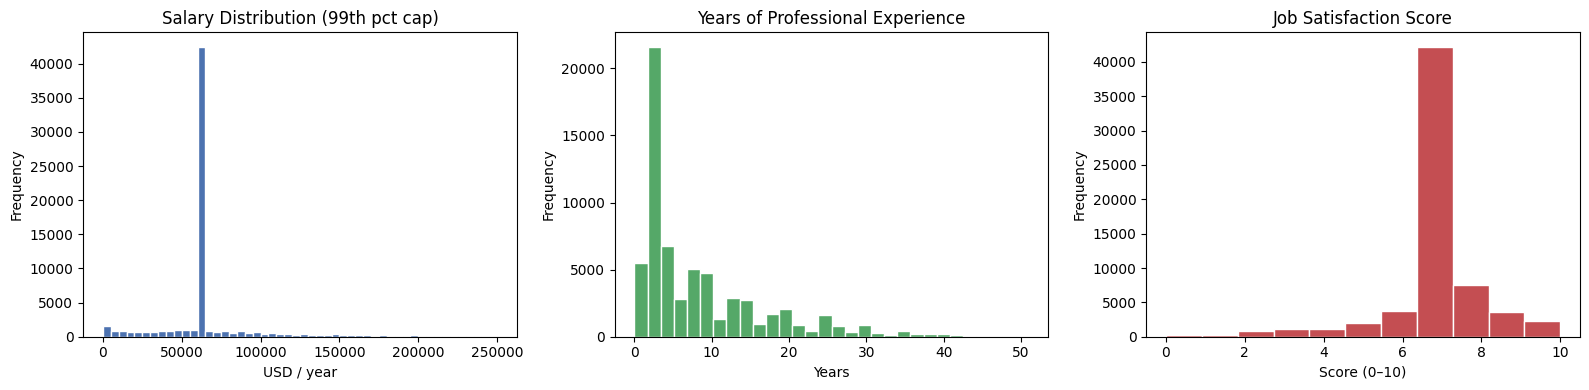

In [17]:
# -- Distribution of key numeric variables -----------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Salary — cap at 99th percentile for readability
cap = df["ConvertedCompYearly"].quantile(0.99)
axes[0].hist(df.loc[df["ConvertedCompYearly"] <= cap, "ConvertedCompYearly"],
             bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Salary Distribution (99th pct cap)")
axes[0].set_xlabel("USD / year")

# Years of professional experience
axes[1].hist(df["YearsCodeProNum"].dropna(), bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("Years of Professional Experience")
axes[1].set_xlabel("Years")

# Job Satisfaction
axes[2].hist(df["JobSat"].dropna(), bins=11, color="#C44E52", edgecolor="white")
axes[2].set_title("Job Satisfaction Score")
axes[2].set_xlabel("Score (0–10)")

for ax in axes:
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [18]:
# -- Outlier detection: IQR on originally-reported salaries only -------------
# Use SQLite (saved pre-imputation in Step 1) to get real salary responses
conn = sqlite3.connect(DB_FILE)
salary_orig = pd.read_sql_query(
    f"SELECT ConvertedCompYearly FROM {TABLE_NAME} WHERE ConvertedCompYearly IS NOT NULL",
    conn
)["ConvertedCompYearly"]

Q1  = salary_orig.quantile(0.25)
Q3  = salary_orig.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

n_outliers = ((salary_orig < lower) | (salary_orig > upper)).sum()
print(f"Reported salaries : {len(salary_orig):,} (originally non-null)")
print(f"IQR range         : ${Q1:,.0f} – ${Q3:,.0f}  |  IQR = ${IQR:,.0f}")
print(f"Outlier bounds    : lower = ${lower:,.0f}  |  upper = ${upper:,.0f}")
print(f"Outliers found    : {n_outliers:,} ({n_outliers/len(salary_orig)*100:.1f}%)")

# Apply bounds to df — only affects originally-reported salary rows
df_clean = df[(df["ConvertedCompYearly"] == 65000) |
              ((df["ConvertedCompYearly"] >= lower) &
               (df["ConvertedCompYearly"] <= upper))].copy()
print(f"\nRows before outlier removal: {len(df):,}")
print(f"Rows after  outlier removal: {len(df_clean):,}")

Reported salaries : 23,435 (originally non-null)
IQR range         : $32,712 – $107,972  |  IQR = $75,260
Outlier bounds    : lower = $-80,177  |  upper = $220,861
Outliers found    : 978 (4.2%)

Rows before outlier removal: 64,950
Rows after  outlier removal: 63,972


> ⚠️ **Why we use SQLite here instead of `df`**
>
> In Step 4, we imputed `ConvertedCompYearly` missing values with the **median ($65,000)**. Since 63.9% of that column was missing, ~41,500 rows now have exactly $65,000. If we ran IQR on the full `df` column, both Q1 and Q3 would land on $65,000 → IQR = $0 → every non-$65K value flagged as an outlier (36% of the dataset — clearly wrong).
>
> **Fix:** query the SQLite database saved in Step 1 (before any imputation) to get only the 23,435 rows where salary was originally reported, and compute IQR on those real values only.

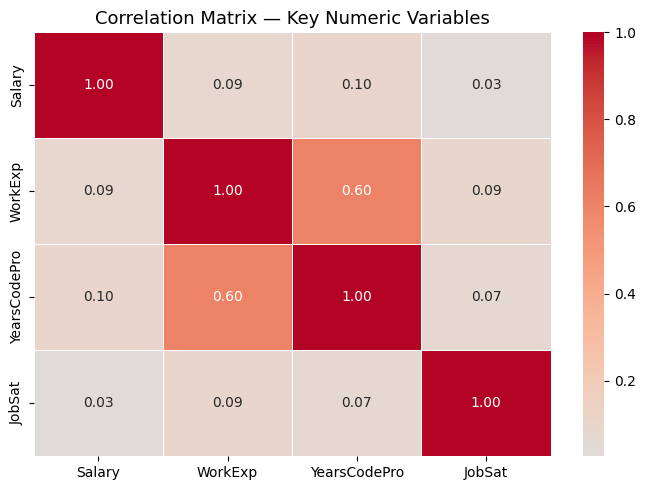

In [19]:
# -- Correlation heatmap (numeric columns) ------------------------------------
num_df = df[["ConvertedCompYearly", "WorkExp", "YearsCodeProNum", "JobSat"]].copy()
num_df.columns = ["Salary", "WorkExp", "YearsCodePro", "JobSat"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Key Numeric Variables", fontsize=13)
plt.tight_layout()
plt.show()

### Findings

**Distributions**
- **Salary** is strongly right-skewed — most respondents earn between $30K–$150K, with a long tail reaching $16.25M. A small number of very high earners pull the mean well above the median.
- **Years of experience** peaks sharply at 1–5 years and decays gradually, reinforcing the Step 6 finding that the community is majority Junior/Mid.
- **Job Satisfaction** is left-skewed toward higher scores — the 7–9 range dominates, with very few respondents rating below 4.

**Outlier Detection (IQR — original salary responses)**
- IQR analysis was applied to the **23,435 originally-reported salary values** (pre-imputation), not the full dataset — otherwise the median-imputed values would collapse the IQR to zero.
- IQR: $32,712 – $107,972 | upper fence: **$220,861**
- **978 salary outliers (4.2%)** were identified above the upper bound — salaries exceeding ~$220K are treated as extreme values for modeling purposes.
- After removing outlier rows, **63,972 rows** remain in `df_clean`.

**Correlation Analysis**
- **YearsCodePro and WorkExp** show the strongest positive correlation — expected, as professional coding years and total work experience naturally move together.
- **Salary and experience** have a modest positive correlation — more experience generally means higher pay, but the relationship is noisy.
- **Job Satisfaction shows near-zero correlation with salary** — money alone does not explain satisfaction, suggesting other factors (remote work, team, purpose) matter more.

---
## Step 8 — Save Clean Dataset
Export the clean dataset to CSV and update the SQLite database with a new table, ready for visualization and dashboard work.

In [20]:
CLEAN_CSV   = "survey_data_clean.csv"
CLEAN_TABLE = "survey_clean"

# -- Export to CSV ------------------------------------------------------------
df_clean.to_csv(CLEAN_CSV, index=False)
print(f"CSV saved       -> {CLEAN_CSV}  ({os.path.getsize(CLEAN_CSV)/1e6:.2f} MB)")

# -- Update SQLite with clean table -------------------------------------------
conn = sqlite3.connect(DB_FILE)
df_clean.to_sql(CLEAN_TABLE, conn, if_exists="replace", index=False)
db_rows = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {CLEAN_TABLE}", conn).iloc[0, 0]
conn.close()
print(f"SQLite updated  -> table: '{CLEAN_TABLE}'  ({db_rows:,} rows)")

# -- Final dataset summary ----------------------------------------------------
print(f"\n{'='*45}")
print(f"  CLEAN DATASET SUMMARY")
print(f"{'='*45}")
print(f"  Rows              : {df_clean.shape[0]:,}")
print(f"  Columns           : {df_clean.shape[1]}")
print(f"  Missing values    : {df_clean.isnull().sum().sum()}")
print(f"  New columns added : Comp_MinMax, Comp_Zscore, YearsCodeProNum, ExperienceLevel")
print(f"{'='*45}")

CSV saved       -> survey_data_clean.csv  (204.73 MB)


SQLite updated  -> table: 'survey_clean'  (63,972 rows)

  CLEAN DATASET SUMMARY
  Rows              : 63,972
  Columns           : 118
  Missing values    : 0
  New columns added : Comp_MinMax, Comp_Zscore, YearsCodeProNum, ExperienceLevel


### Findings

The full data wrangling pipeline is now complete. The clean dataset has been saved to two outputs:

| Output | Details |
|---|---|
| `survey_data_clean.csv` | 204.73 MB, ready for Cognos / Looker Studio import |
| SQLite table `survey_clean` | 63,972 rows, queryable for any further analysis |

**Pipeline summary — what changed from raw to clean:**

| Stage | Raw | Clean |
|---|---|---|
| Rows | 65,437 | 63,972 (−1,465: 487 duplicates + 978 salary outliers) |
| Columns | 114 | 118 (+4 engineered features) |
| Missing values | ~2.8M | 0 |
| Salary range | $1 – $16.25M | $0 – $220,861 (IQR-bounded) |

**New columns in the clean dataset:**
- `Comp_MinMax` — salary scaled to [0, 1]
- `Comp_Zscore` — salary in standard deviations from the mean
- `YearsCodeProNum` — professional experience as a numeric value
- `ExperienceLevel` — Junior / Mid / Senior / Expert label

The dataset is ready for dashboard building (Step 6 of the project pipeline) and the final presentation.

### Slides 7 & 8 — Job Postings & Popular Languages by Salary
> Charts generated from Module 1 data collection notebooks:
> - **Job Postings:** [](Module1_Job_Postings.ipynb) — data from Jobs API ()
> - **Popular Languages:** [](Module1_Popular_Languages.ipynb) — data from web scraping ()

Slide 7 — Job Postings by Location


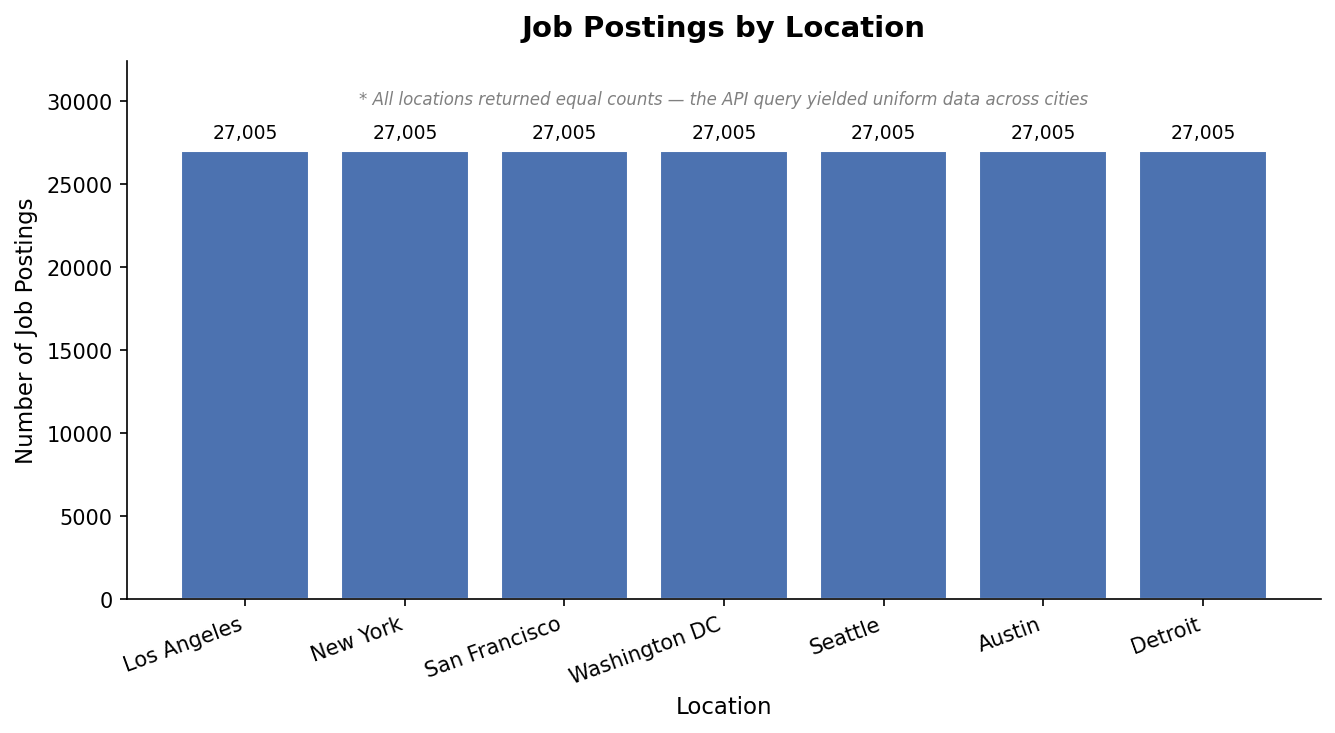

Slide 8 — Popular Languages by Salary


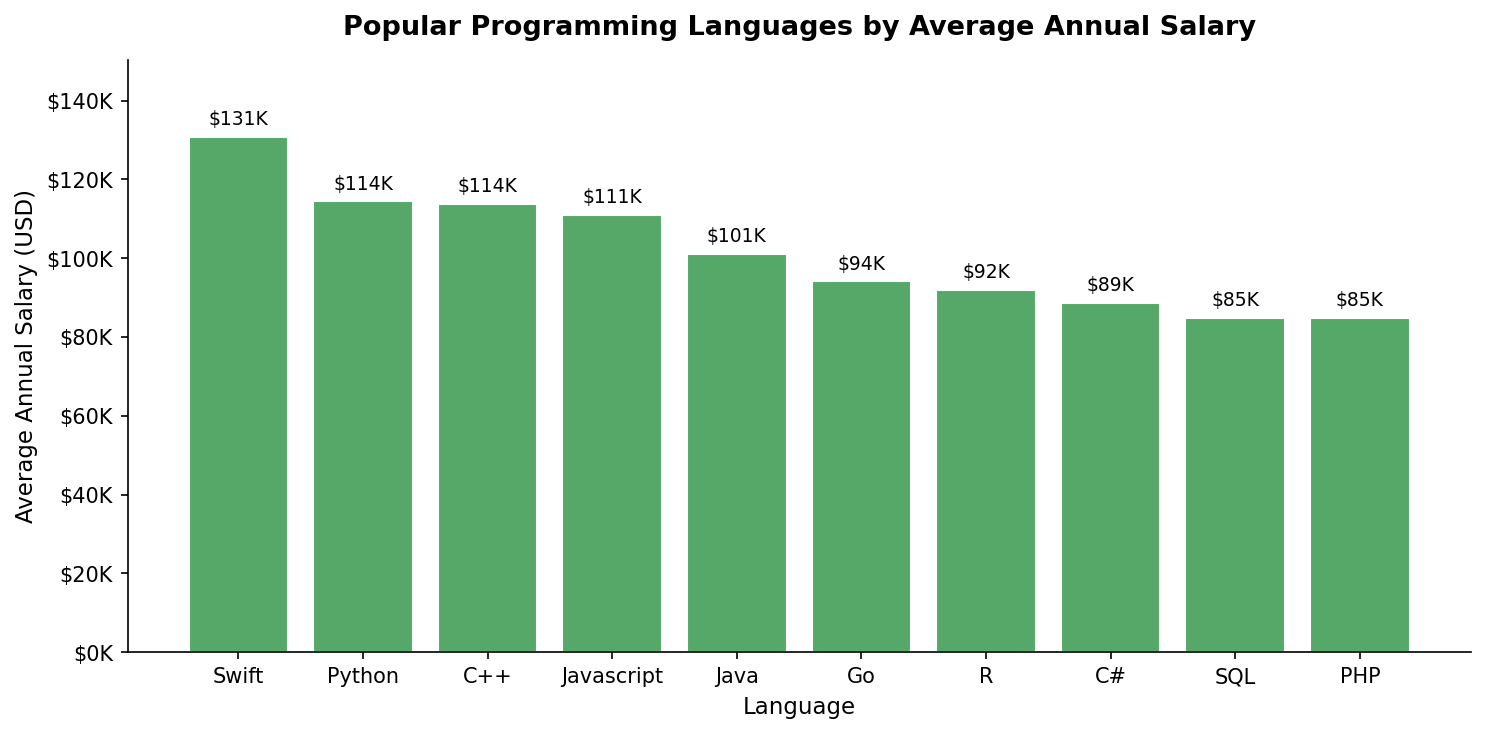

In [21]:
# -- Display Module 1 charts (generated by dedicated notebooks) -------------
from IPython.display import Image, display
import os

for fname, title in [
    ("charts/job_postings.png",      "Slide 7 — Job Postings by Location"),
    ("charts/popular_languages.png", "Slide 8 — Popular Languages by Salary"),
]:
    if os.path.exists(fname):
        print(title)
        display(Image(fname))
    else:
        print(f"Run the Module 1 notebook to generate: {fname}")


---
## Step 9 — Data Visualization
Charts organized to match the presentation slide structure. Horizontal bar charts are used for technology rankings (labels are long); bar charts for demographic distributions; box plots for salary comparisons across groups; line charts for trends over experience.

### Slide 9 — Programming Language Trends (Current vs. Next Year)

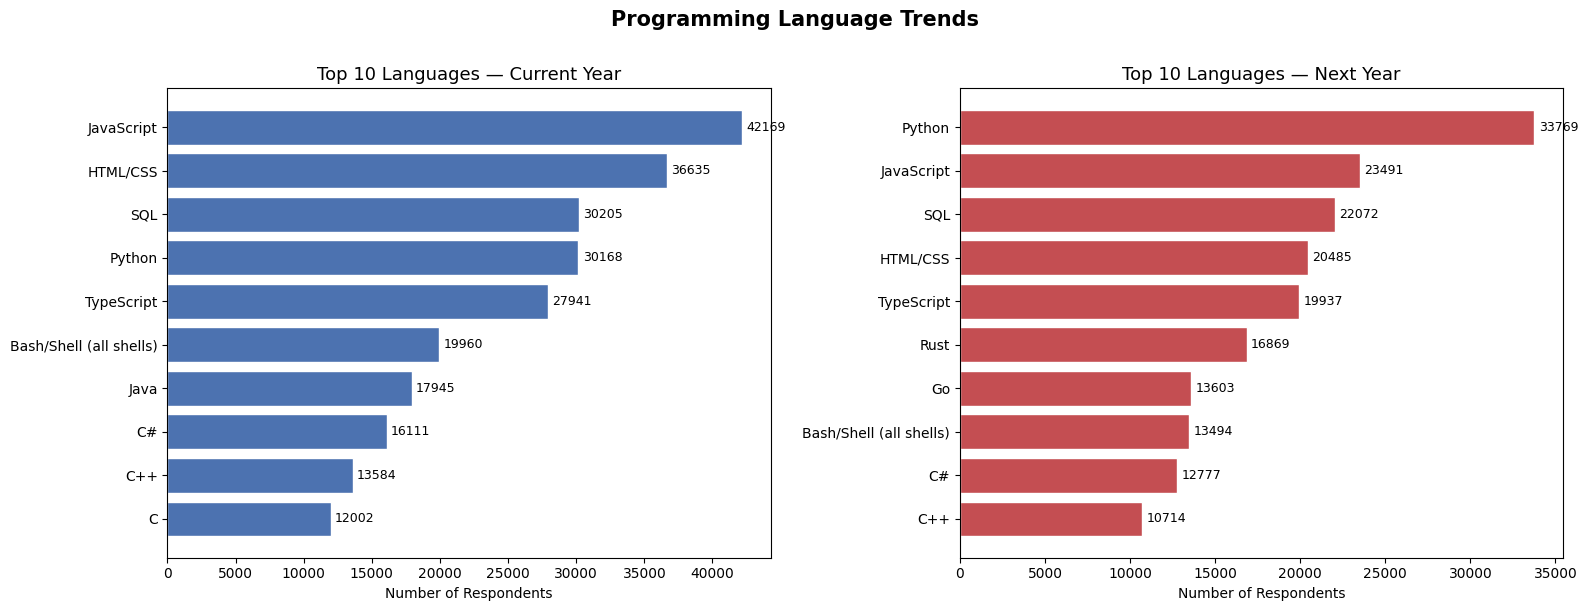

In [22]:
# Horizontal bar chosen over pie: 10 categories — pie gets too cluttered
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title, color in [
    (axes[0], "LanguageHaveWorkedWith",  "Top 10 Languages — Current Year", "#4C72B0"),
    (axes[1], "LanguageWantToWorkWith",  "Top 10 Languages — Next Year",    "#C44E52"),
]:
    top = top_technologies(df_clean, col, n=10).sort_values("count")
    ax.barh(top[col], top["count"], color=color, edgecolor="white")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Number of Respondents")
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.suptitle("Programming Language Trends", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Slide 11 — Database Trends (Current vs. Next Year)

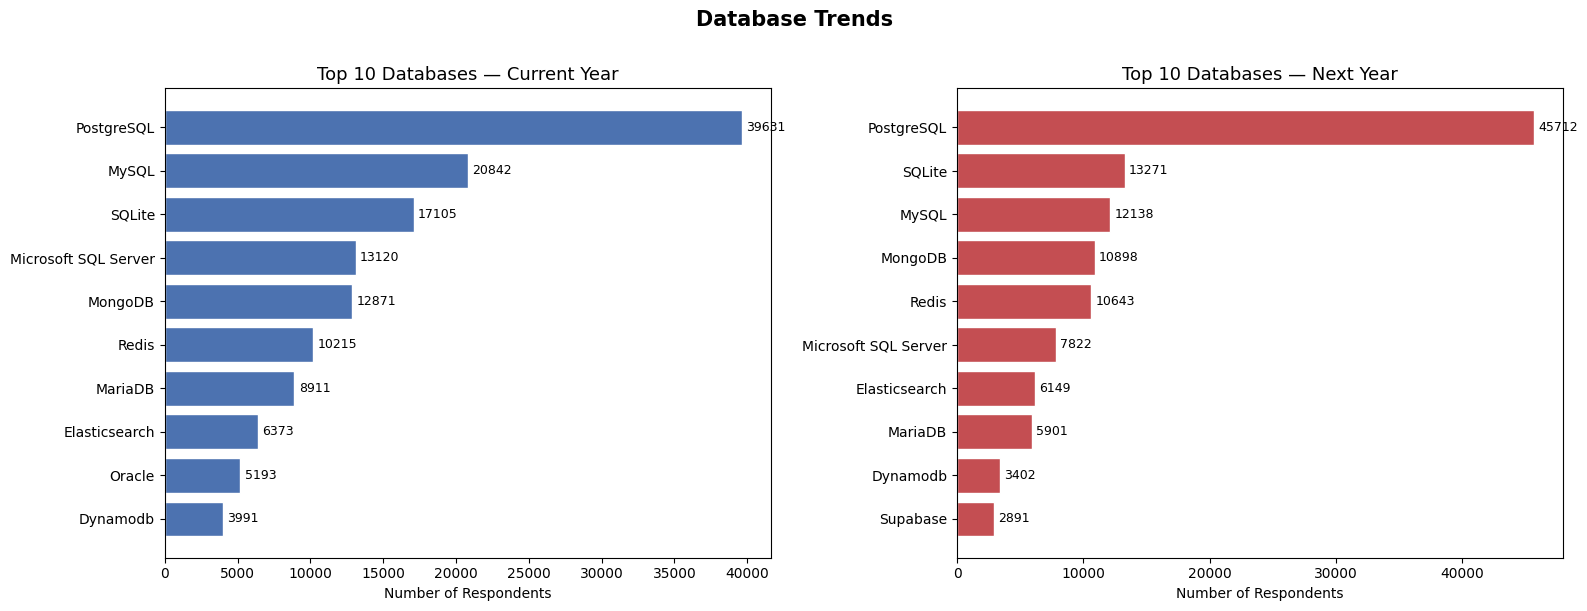

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title, color in [
    (axes[0], "DatabaseHaveWorkedWith", "Top 10 Databases — Current Year", "#4C72B0"),
    (axes[1], "DatabaseWantToWorkWith", "Top 10 Databases — Next Year",    "#C44E52"),
]:
    top = top_technologies(df_clean, col, n=10).sort_values("count")
    ax.barh(top[col], top["count"], color=color, edgecolor="white")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Number of Respondents")
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.suptitle("Database Trends", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Slide 16 — Demographics

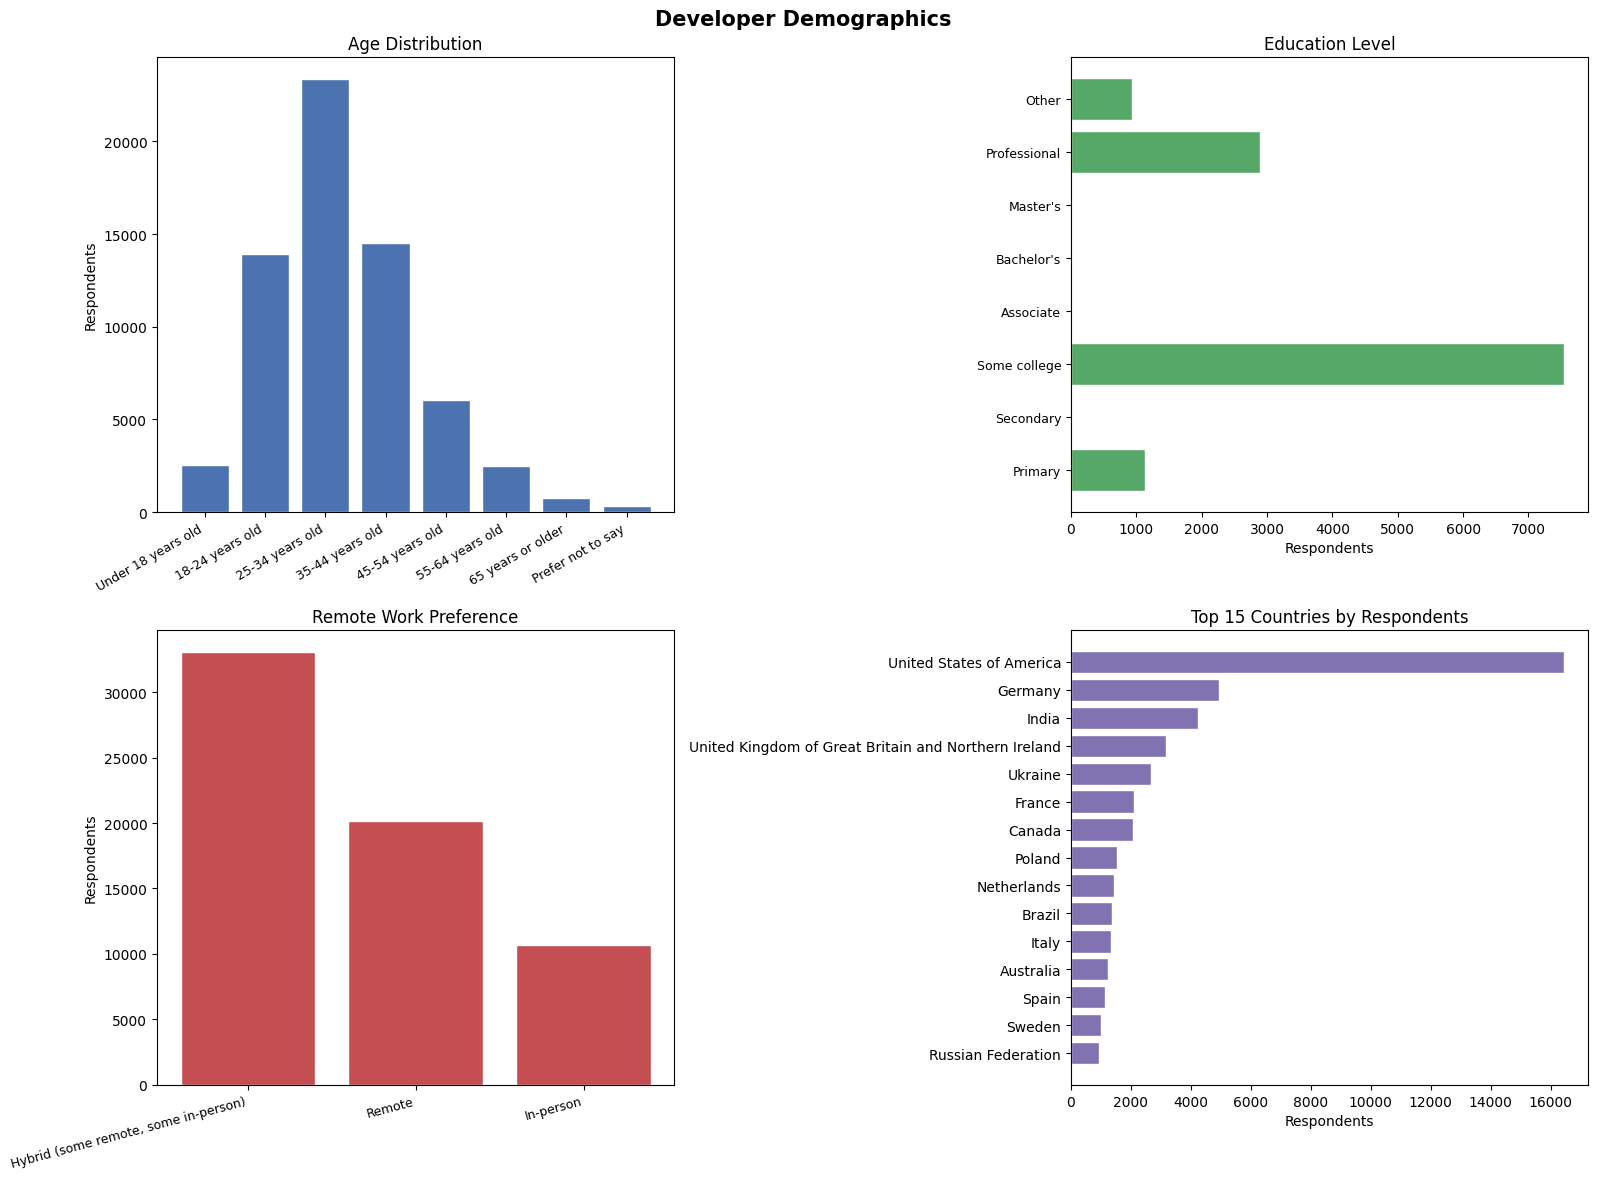

In [24]:
# Bar chart chosen over pie for all — too many categories for pie to be readable
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution
age_order = ["Under 18 years old","18-24 years old","25-34 years old",
             "35-44 years old","45-54 years old","55-64 years old",
             "65 years or older","Prefer not to say"]
age_counts = df_clean["Age"].value_counts().reindex(age_order).fillna(0)
axes[0,0].bar(range(len(age_counts)), age_counts.values, color="#4C72B0", edgecolor="white")
axes[0,0].set_xticks(range(len(age_counts)))
axes[0,0].set_xticklabels(age_counts.index, rotation=30, ha="right", fontsize=9)
axes[0,0].set_title("Age Distribution", fontsize=12)
axes[0,0].set_ylabel("Respondents")

# Education level
ed_order = ["Primary/elementary school","Secondary school",
            "Some college/university study without earning a degree",
            "Associate degree","Bachelor's degree (B.A., B.S., B.Eng., etc.)",
            "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
            "Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Something else"]
short_labels = ["Primary","Secondary","Some college","Associate","Bachelor's","Master's","Professional","Other"]
ed_counts = df_clean["EdLevel"].value_counts().reindex(ed_order).fillna(0)
axes[0,1].barh(range(len(ed_counts)), ed_counts.values, color="#55A868", edgecolor="white")
axes[0,1].set_yticks(range(len(ed_counts)))
axes[0,1].set_yticklabels(short_labels, fontsize=9)
axes[0,1].set_title("Education Level", fontsize=12)
axes[0,1].set_xlabel("Respondents")

# Remote work preference
remote_counts = df_clean["RemoteWork"].value_counts()
axes[1,0].bar(range(len(remote_counts)), remote_counts.values, color="#C44E52", edgecolor="white")
axes[1,0].set_xticks(range(len(remote_counts)))
axes[1,0].set_xticklabels(remote_counts.index, rotation=15, ha="right", fontsize=9)
axes[1,0].set_title("Remote Work Preference", fontsize=12)
axes[1,0].set_ylabel("Respondents")

# Top 15 countries
top_countries = df_clean["Country"].value_counts().head(15).sort_values()
axes[1,1].barh(top_countries.index, top_countries.values, color="#8172B2", edgecolor="white")
axes[1,1].set_title("Top 15 Countries by Respondents", fontsize=12)
axes[1,1].set_xlabel("Respondents")

plt.suptitle("Developer Demographics", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Salary & Experience Analysis (Appendix / Dashboard support)

Rows with original salary + job satisfaction: 15,437


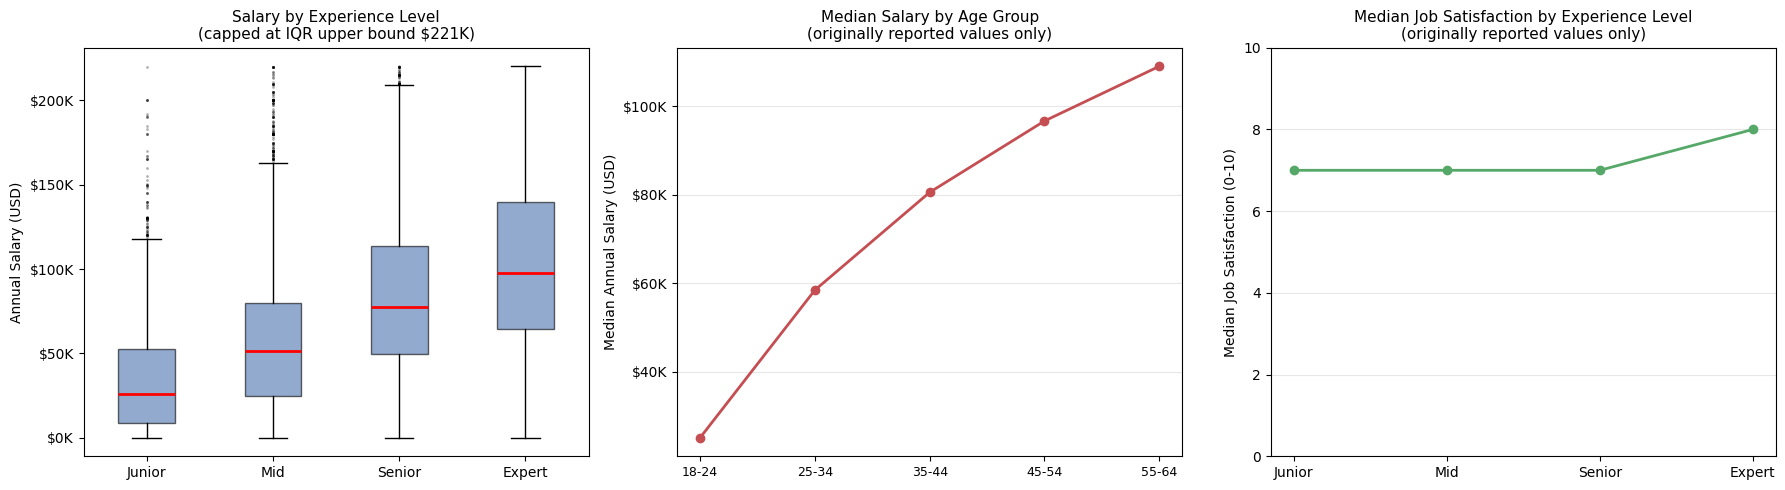

In [25]:
# -- Use original non-imputed values from SQLite (same approach as Step 7) ---
# Imputation set ~64% of salary and ~55% of JobSat to their medians,
# making every group median identical. Original values give real variation.
conn = sqlite3.connect(DB_FILE)
orig = pd.read_sql_query(
    f"SELECT ResponseId, ConvertedCompYearly AS SalaryOrig, JobSat AS JobSatOrig "
    f"FROM {TABLE_NAME} "
    f"WHERE ConvertedCompYearly IS NOT NULL AND JobSat IS NOT NULL",
    conn
)
conn.close()

# Merge with df_clean to get ExperienceLevel and Age for each row
orig = orig.merge(df_clean[['ResponseId', 'ExperienceLevel', 'Age']], on='ResponseId', how='inner')
print(f'Rows with original salary + job satisfaction: {len(orig):,}')

# Cap salary at IQR upper bound from Step 7 — removes extreme outliers from box plot
SALARY_CAP = 220_861
orig_capped = orig[orig['SalaryOrig'] <= SALARY_CAP]

exp_order = ['Junior', 'Mid', 'Senior', 'Expert']
age_order  = ['18-24 years old','25-34 years old','35-44 years old',
              '45-54 years old','55-64 years old']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot: salary by experience level — capped at IQR upper bound
data_by_exp = [orig_capped.loc[orig_capped['ExperienceLevel'] == lvl, 'SalaryOrig'].values
               for lvl in exp_order]
axes[0].boxplot(data_by_exp, tick_labels=exp_order, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_title('Salary by Experience Level\n(capped at IQR upper bound $221K)', fontsize=11)
axes[0].set_ylabel('Annual Salary (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Line chart: median salary by age group (original reported values only)
age_salary = (orig_capped.groupby('Age')['SalaryOrig']
              .median()
              .reindex(age_order)
              .dropna())
axes[1].plot(range(len(age_salary)), age_salary.values, marker='o', color='#C44E52', linewidth=2)
axes[1].set_xticks(range(len(age_salary)))
axes[1].set_xticklabels(['18-24','25-34','35-44','45-54','55-64'], fontsize=9)
axes[1].set_title('Median Salary by Age Group\n(originally reported values only)', fontsize=11)
axes[1].set_ylabel('Median Annual Salary (USD)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].grid(axis='y', alpha=0.3)

# Line chart: median job satisfaction by experience level (original values)
jobsat_by_exp = (orig.groupby('ExperienceLevel')['JobSatOrig']
                 .median()
                 .reindex(exp_order))
axes[2].plot(exp_order, jobsat_by_exp.values, marker='o', color='#55A868', linewidth=2)
axes[2].set_title('Median Job Satisfaction by Experience Level\n(originally reported values only)', fontsize=11)
axes[2].set_ylabel('Median Job Satisfaction (0-10)')
axes[2].set_ylim(0, 10)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
